# e-f Gate Tuneup

In this reference notebook, you'll learn how to use LabOne Q's [logical signals lines](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/02_logical_signals/concepts/index.html) to perform tuneup of a pi-pulse working on the e-f transition of a superconducitng transmon qubit. This functionality requires an SHFSG or SHFQC and relies on using the command table instead of `playWave` commands.

## 0. General Imports and Definitions

### 0.1 Python Imports

In [1]:
# Helpers:
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation

# LabOne Q:
from laboneq.simple import *

## 1. Define Device Setup and Calibration

### 1.1 Define a Device Setup

We'll generate a device setup and some qubit objects using a set of pre-defined parameters in a helper function. 

In [2]:
# specify the number of qubits you want to use
number_of_qubits = 2

# generate the device setup and the qubit objects using a helper function
device_setup, qubits = generate_device_setup_qubits(
    number_qubits=number_of_qubits,
    pqsc=[{"serial": "DEV10001"}],
    hdawg=[
        {
            "serial": "DEV8001",
            "number_of_channels": 8,
            "options": None,
        }
    ],
    shfqc=[
        {
            "serial": "DEV12001",
            "number_of_channels": 6,
            "readout_multiplex": 6,
            "options": None,
        }
    ],
    multiplex_drive_lines=True,
    include_flux_lines=True,
    server_host="localhost",
    setup_name=f"my_{number_of_qubits}_tunable_qubit_setup",
)

q0, q1 = qubits[:2]

In [3]:
# use emulation mode - no connection to instruments
use_emulation = True

# create and connect to a session
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

[2026.06.30 15:26:10.053] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/pulse-sequences/laboneq_output/log
[2026.06.30 15:26:10.056] INFO    VERSION: laboneq 26.4.0
[2026.06.30 15:26:10.056] INFO    Connecting to data server at localhost:8004
[2026.06.30 15:26:10.057] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.30 15:26:10.058] INFO    Configuring the device setup
[2026.06.30 15:26:10.084] INFO    The device setup is configured


## 2. e-f Gate Tune-up

Sweep the pulse amplitude of a qubit drive pulse to determine the ideal amplitudes to drive qubit from excited to second excited state 
- assumes that a pi-pulse to reach the e state is already calibrated

### 2.1 Define the Experiment

In [4]:
## define pulses

# qubit pi pulse for first excited state
x180 = pulse_library.drag(uid="x180", length=23e-9, amplitude=0.5, sigma=0.3, beta=0.2)

# pulse to be calibrated for e-f transition - amplitude will be swept
ef_pulse = pulse_library.drag(
    uid="ef_pulse", length=32e-9, amplitude=1.0, sigma=0.3, beta=0.2
)

# readout drive pulse
readout_pulse = pulse_library.const(uid="readout_pulse", length=400e-9, amplitude=0.2)
# readout integration weights
readout_weighting_function = pulse_library.const(
    uid="readout_weighting_function", length=400e-9, amplitude=0.8
)

In [5]:
# set up sweep parameter - drive amplitude
start = 0.1
stop = 1
count = 25
amplitude_sweep = LinearSweepParameter(
    uid="amplitude", start=start, stop=stop, count=count
)

# number of averages
average_exponent = 10  # used for 2^n averages, n=average_exponent, maximum: n = 17

# Create Experiment
exp_ef_gate = Experiment(
    uid="e-f Tuneup",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("drive_ef"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)
## experimental pulse sequence
# outer loop - real-time, cyclic averaging in standard integration mode
with exp_ef_gate.acquire_loop_rt(
    uid="shots",
    count=pow(2, average_exponent),
    averaging_mode=AveragingMode.CYCLIC,
    acquisition_type=AcquisitionType.INTEGRATION,
):
    # inner loop - real-time sweep of qubit drive pulse amplitude
    with exp_ef_gate.sweep(uid="sweep", parameter=amplitude_sweep):
        # qubit excitation - pulse amplitude will be swept
        with exp_ef_gate.section(
            uid="qubit_excitation",
            on_system_grid=True,
            alignment=SectionAlignment.RIGHT,
        ):
            exp_ef_gate.play(signal="drive", pulse=x180)
        with exp_ef_gate.section(
            uid="qubit_ef_excitation",
            play_after="qubit_excitation",
            on_system_grid=True,
            alignment=SectionAlignment.LEFT,
        ):
            exp_ef_gate.play(
                signal="drive_ef", pulse=ef_pulse, amplitude=amplitude_sweep
            )
        # qubit readout pulse and data acquisition
        with exp_ef_gate.section(uid="qubit_readout", play_after="qubit_ef_excitation"):
            # play readout pulse
            exp_ef_gate.play(signal="measure", pulse=readout_pulse)
            # signal data acquisition
            exp_ef_gate.acquire(
                signal="acquire",
                handle="ac_0",
                kernel=readout_weighting_function,
            )
        # relax time after readout - for signal processing and qubit relaxation to groundstate
        with exp_ef_gate.section(uid="relax", length=100e-9):
            exp_ef_gate.reserve(signal="measure")

In [6]:
# define signal maps for qubit 0
map_q0 = {
    "drive": q0.signals["drive"],
    "drive_ef": q0.signals["drive_ef"],
    "measure": q0.signals["measure"],
    "acquire": q0.signals["acquire"],
}
# ... - and qubit 1
map_q1 = {
    "drive": q1.signals["drive"],
    "drive_ef": q1.signals["drive_ef"],
    "measure": q1.signals["measure"],
    "acquire": q1.signals["acquire"],
}

### 2.2 Run the Experiment and Plot the Pulse Sequence

In [7]:
# set signal map to qubit 0
exp_ef_gate.set_signal_map(map_q1)

# run experiment on qubit 0
compiled_exp_ef_gate = session.compile(exp_ef_gate)
ef_gate_results = session.run(compiled_exp_ef_gate)

[2026.06.30 15:26:10.111] INFO    Starting LabOne Q Compiler run...
[2026.06.30 15:26:10.112] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 15:26:10.112] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 15:26:10.113] INFO    Resolved modulation type of oscillator on signal: 'drive_ef' to Hardware
[2026.06.30 15:26:10.113] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 15:26:10.114] INFO    Schedule completed. [0.000 s]
[2026.06.30 15:26:10.119] INFO    Code generation completed for all AWGs. [0.005 s]
[2026.06.30 15:26:10.119] INFO    Completed compilation step 1 of 1. [0.005 s]
[2026.06.30 15:26:10.122] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 15:26:10.122] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 15:26:10.123] INFO     ─────────────────────────────────────────────

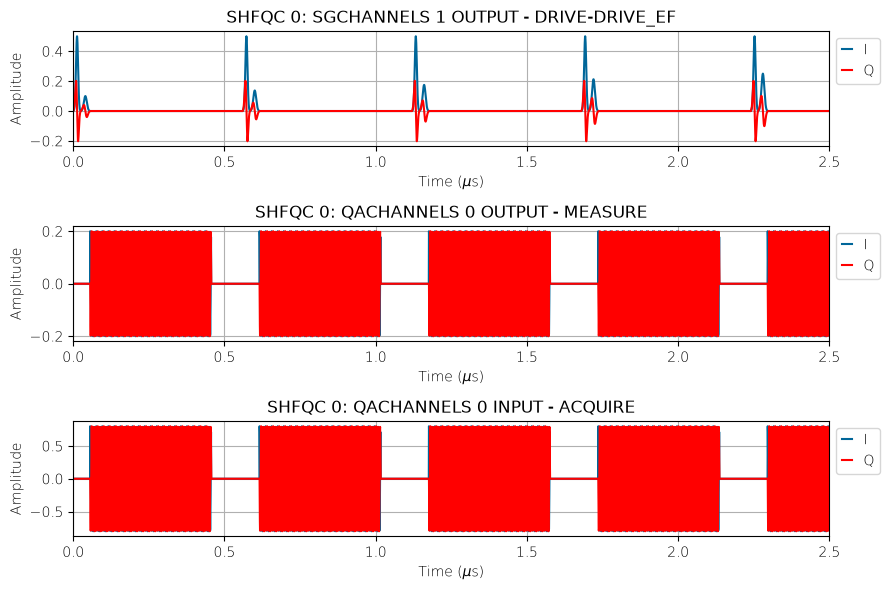

In [8]:
# Plot simulated output signals
plot_simulation(compiled_exp_ef_gate, start_time=0, length=2.5e-6)